# TQQQレジーム戦略の全パラメータ範囲検証

## tl;dr

- 指定範囲21,840組・43,680遅延ケースを走査し、4,752組（21.8%）が0日・1日遅延の両方でCAGR 30%以上。
- 粗い全域走査の最良点は150日・40日・32%・許容帯3%で、両遅延中の最低CAGRは41.20%。
- 1日刻み再探索では147〜151日・38〜46日・31〜32%・許容帯3%に連続した高成績領域がある。
- KMLMSIMはTestfolio内部バックテストAPIから日次リターンを取得して防御配分へ組み込む。GLDSIM・IEISIMはまだローカル代理系列。

## Context & Methods

### Key Assumptions

- 検証期間: 1996-01-02〜2026-04-17
- リスクオン: repositoryのTQQQ canonical stitched return
- 防御配分: KMLMSIM 1/3、金 1/3、VFITX 1/3
- 売買コスト: 5bp
- 当日終値情報は、0日遅延では翌取引日、1日追加遅延では翌々取引日のリターンから適用
- SPY SMAにはTestfolio型の3%ヒステリシスを適用

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display, Image

ROOT = Path.cwd()
if ROOT.name != '20260811_Safer_But_Good_Approaches_Exploration':
    ROOT = Path('/Users/harukishibuya/Documents/LETF_simulation/20260811_Safer_But_Good_Approaches_Exploration')
OUTPUT = ROOT / 'output'

grid = pd.read_csv(OUTPUT / 'parameter_grid.csv')
baseline = pd.read_csv(OUTPUT / 'baseline_delay_summary.csv')
quality = pd.read_csv(OUTPUT / 'data_quality.csv')
refinement_grid = pd.read_csv(OUTPUT / 'refinement_parameter_grid.csv')
refinement_robust = pd.read_csv(OUTPUT / 'refinement_robust_summary.csv')
print(f'Grid rows: {len(grid):,}; parameter sets: {len(grid) // 2:,}')

Grid rows: 43,680; parameter sets: 21,840


## Data

In [2]:
relevant_quality = quality[quality['series'].isin([
    'ndx', 'tqqq_return', 'spy', 'bond', 'gold_spot', 'gld',
    'defensive_return', 'cash_return'
])][['series', 'rows', 'start', 'end', 'nulls', 'duplicate_dates', 'min', 'max']]
display(relevant_quality)

,series,rows,start,end,nulls,duplicate_dates,min,max
0,ndx,7875,1995-01-03,2026-04-17,0,0,398.000000,26672.429688
2,tqqq_return,7875,1995-01-03,2026-04-17,0,0,-0.344652,0.562900
3,spy,7875,1995-01-03,2026-04-17,0,0,26.443813,708.315247
4,bond,7875,1995-01-03,2026-04-17,0,0,2.422636,10.036094
5,gld,7875,2004-11-18,2026-04-17,2489,0,41.259998,495.899994
6,gold_spot,7875,1995-01-03,2026-04-17,0,0,252.800000,1895.000000
13,cash_return,7875,1995-01-03,2026-04-17,0,0,0.000000,0.000247
14,defensive_return,7875,1995-01-03,2026-04-17,0,0,-0.040923,0.039333


`gld`の欠損はETF設定前で想定どおり。2004年11月以前はBank of EnglandのUSD金価格を使用する。分析に用いる合成`gold_return`、`defensive_return`には欠損がない。

## Results

In [3]:
baseline_display = baseline[[
    'delay', 'cagr', 'volatility', 'max_drawdown',
    'dotcom_max_drawdown', 'ending_value_1000', 'risk_on_share', 'switches'
]].copy()
for column in ['cagr', 'volatility', 'max_drawdown', 'dotcom_max_drawdown', 'risk_on_share']:
    baseline_display[column] = baseline_display[column].map(lambda x: f'{x:.2%}')
baseline_display['ending_value_1000'] = baseline_display['ending_value_1000'].map(lambda x: f'${x:,.0f}')
display(baseline_display)

,delay,cagr,volatility,max_drawdown,dotcom_max_drawdown,ending_value_1000,risk_on_share,switches
0,0,38.56%,43.73%,-54.89%,-20.75%,"$19,484,940",65.20%,48
1,1,37.25%,43.90%,-55.37%,-23.10%,"$14,620,916",65.18%,48


In [4]:
robust = (
    grid.groupby(['ma_window', 'vol_window', 'vol_threshold', 'tolerance'])
        .agg(
            min_cagr=('cagr', 'min'),
            mean_cagr=('cagr', 'mean'),
            worst_max_drawdown=('max_drawdown', 'min'),
            worst_dotcom_drawdown=('dotcom_max_drawdown', 'min'),
        )
        .reset_index()
)
print(f'0日・1日遅延の両方でCAGR 30%以上: {(robust.min_cagr >= .30).sum()} / {len(robust)} parameter sets')

display(robust.sort_values(['min_cagr', 'mean_cagr'], ascending=False).head(15))

top_refined = refinement_robust.head(15).copy()
display(top_refined)
plateau = refinement_robust[
    refinement_robust.ma_window.between(144, 152)
    & refinement_robust.vol_window.between(42, 48)
    & refinement_robust.vol_threshold.between(.31, .33)
    & refinement_robust.tolerance.between(.02, .04)
]
print(f'局所帯: {len(plateau)}組; 0日・1日遅延の両方で30%以上={(plateau.min_delay_cagr >= .30).mean():.1%}; 中央値={plateau.min_delay_cagr.median():.2%}')

0日・1日遅延の両方でCAGR 30%以上: 4752 / 21840 parameter sets


,ma_window,vol_window,vol_threshold,tolerance,min_cagr,mean_cagr,worst_max_drawdown,worst_dotcom_drawdown
483,150,40,0.32,0.03,0.411954,0.414018,-0.598700,-0.370779
478,150,40,0.31,0.03,0.404946,0.418448,-0.598700,-0.231172
7303,175,40,0.31,0.03,0.404193,0.409868,-0.553702,-0.231172
5938,170,40,0.31,0.03,0.402840,0.410569,-0.608012,-0.231172
588,150,45,0.32,0.03,0.402802,0.412846,-0.598700,-0.339286
4573,165,40,0.31,0.03,0.399825,0.410126,-0.604731,-0.231172
1843,155,40,0.31,0.03,0.397544,0.402987,-0.604731,-0.231172
598,150,45,0.34,0.03,0.396943,0.405608,-0.598700,-0.331549
3208,160,40,0.31,0.03,0.395674,0.402448,-0.604731,-0.231172
5937,170,40,0.31,0.02,0.393886,0.394335,-0.570267,-0.300626


,ma_window,vol_window,vol_threshold,tolerance,min_delay_cagr,mean_delay_cagr,worst_max_drawdown,worst_dotcom_drawdown
0,150,40,0.32,0.03,0.411954,0.414018,-0.5987,-0.370779
1,151,38,0.31,0.03,0.411875,0.412105,-0.5987,-0.231014
2,150,38,0.31,0.03,0.410349,0.412513,-0.5987,-0.231014
3,151,40,0.32,0.03,0.409616,0.413614,-0.5987,-0.370779
4,151,41,0.31,0.03,0.409413,0.414892,-0.5987,-0.231014
5,147,41,0.31,0.03,0.408016,0.408822,-0.5987,-0.231014
6,148,41,0.31,0.03,0.408016,0.408822,-0.5987,-0.231014
7,150,41,0.31,0.03,0.407890,0.415308,-0.5987,-0.231014
8,152,38,0.31,0.03,0.406990,0.407541,-0.5987,-0.231014
9,151,40,0.31,0.03,0.406466,0.418022,-0.5987,-0.231172


局所帯: 567組; 0日・1日遅延の両方で30%以上=100.0%; 中央値=36.46%


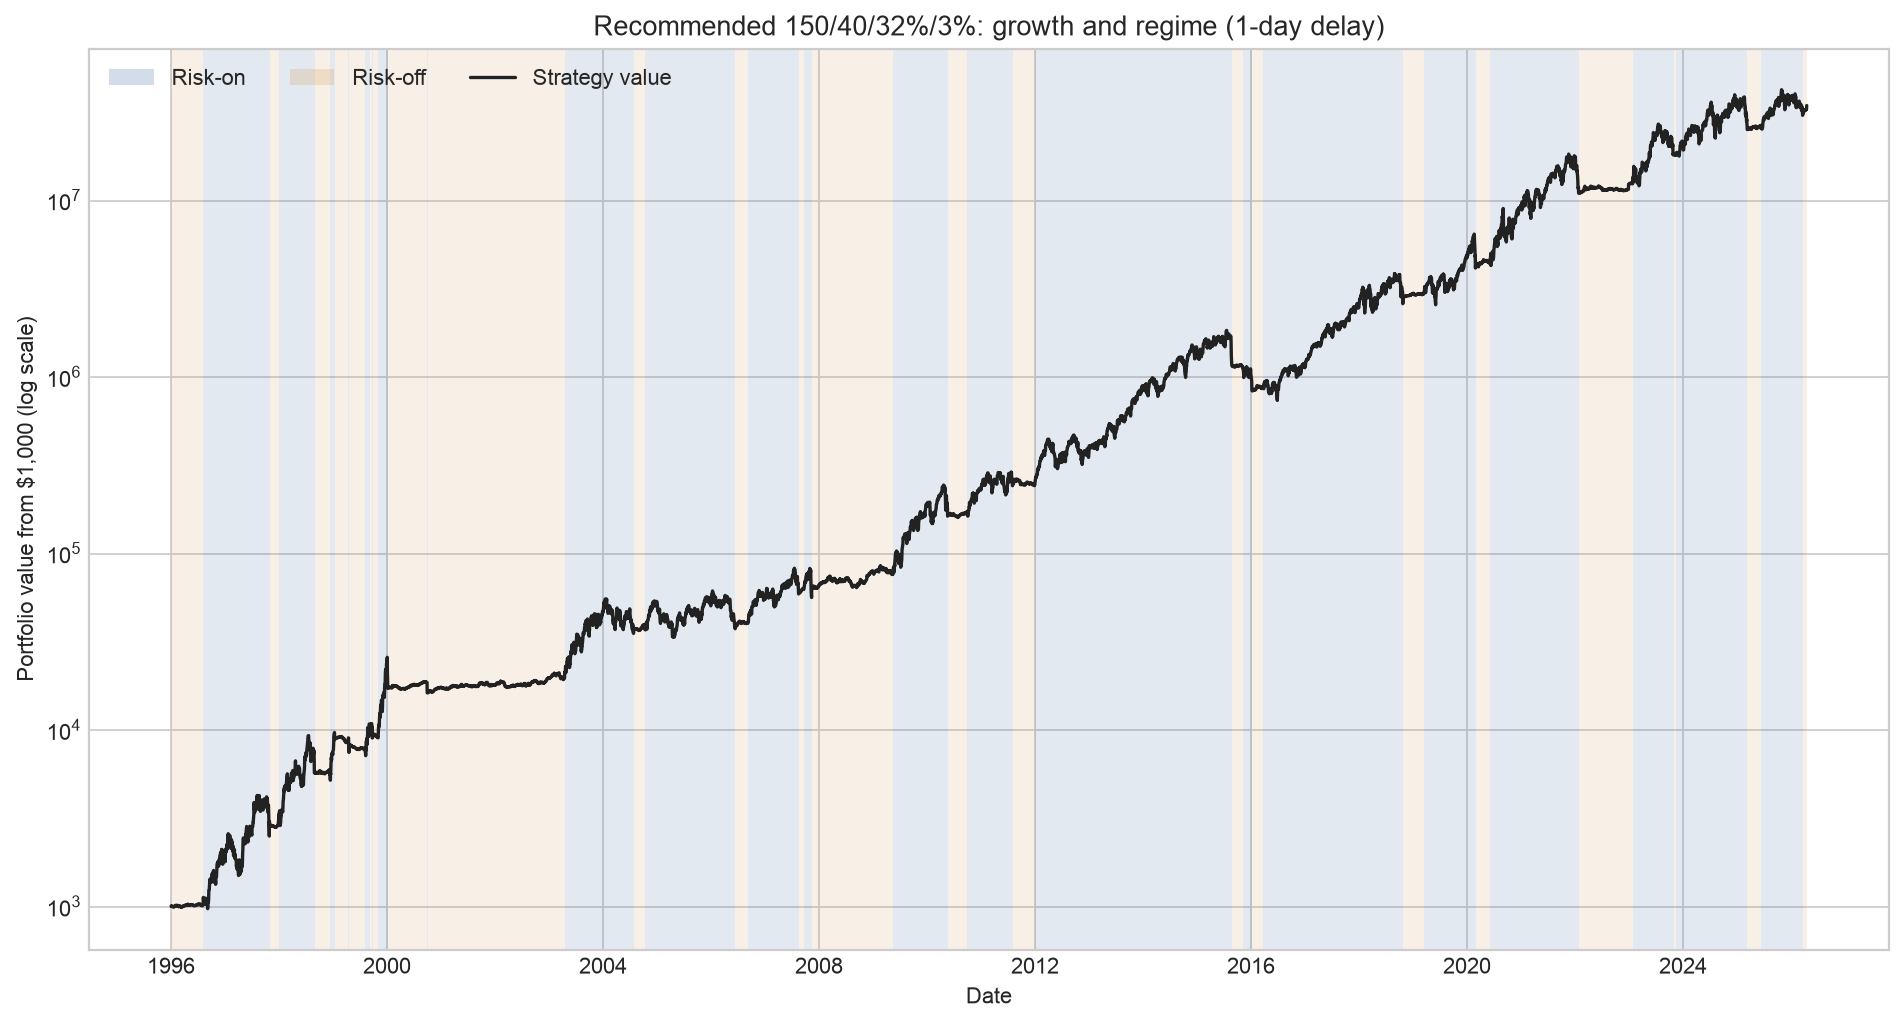

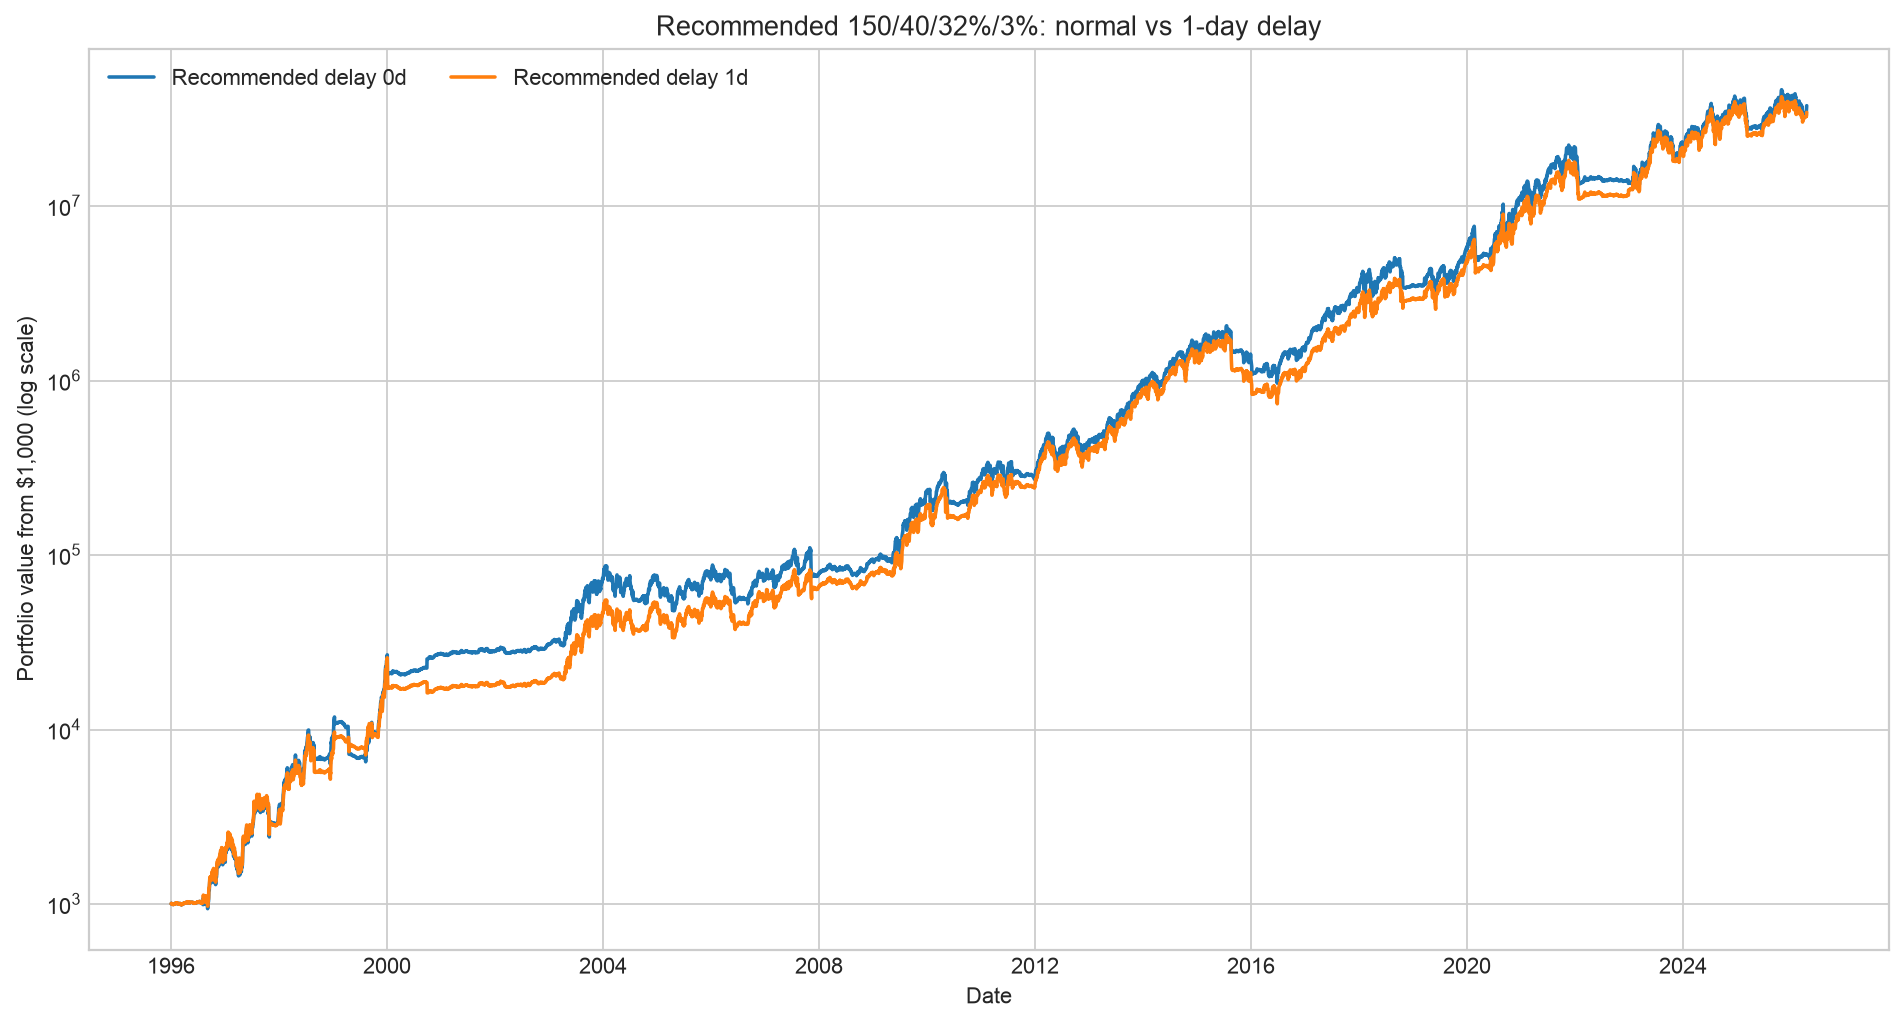

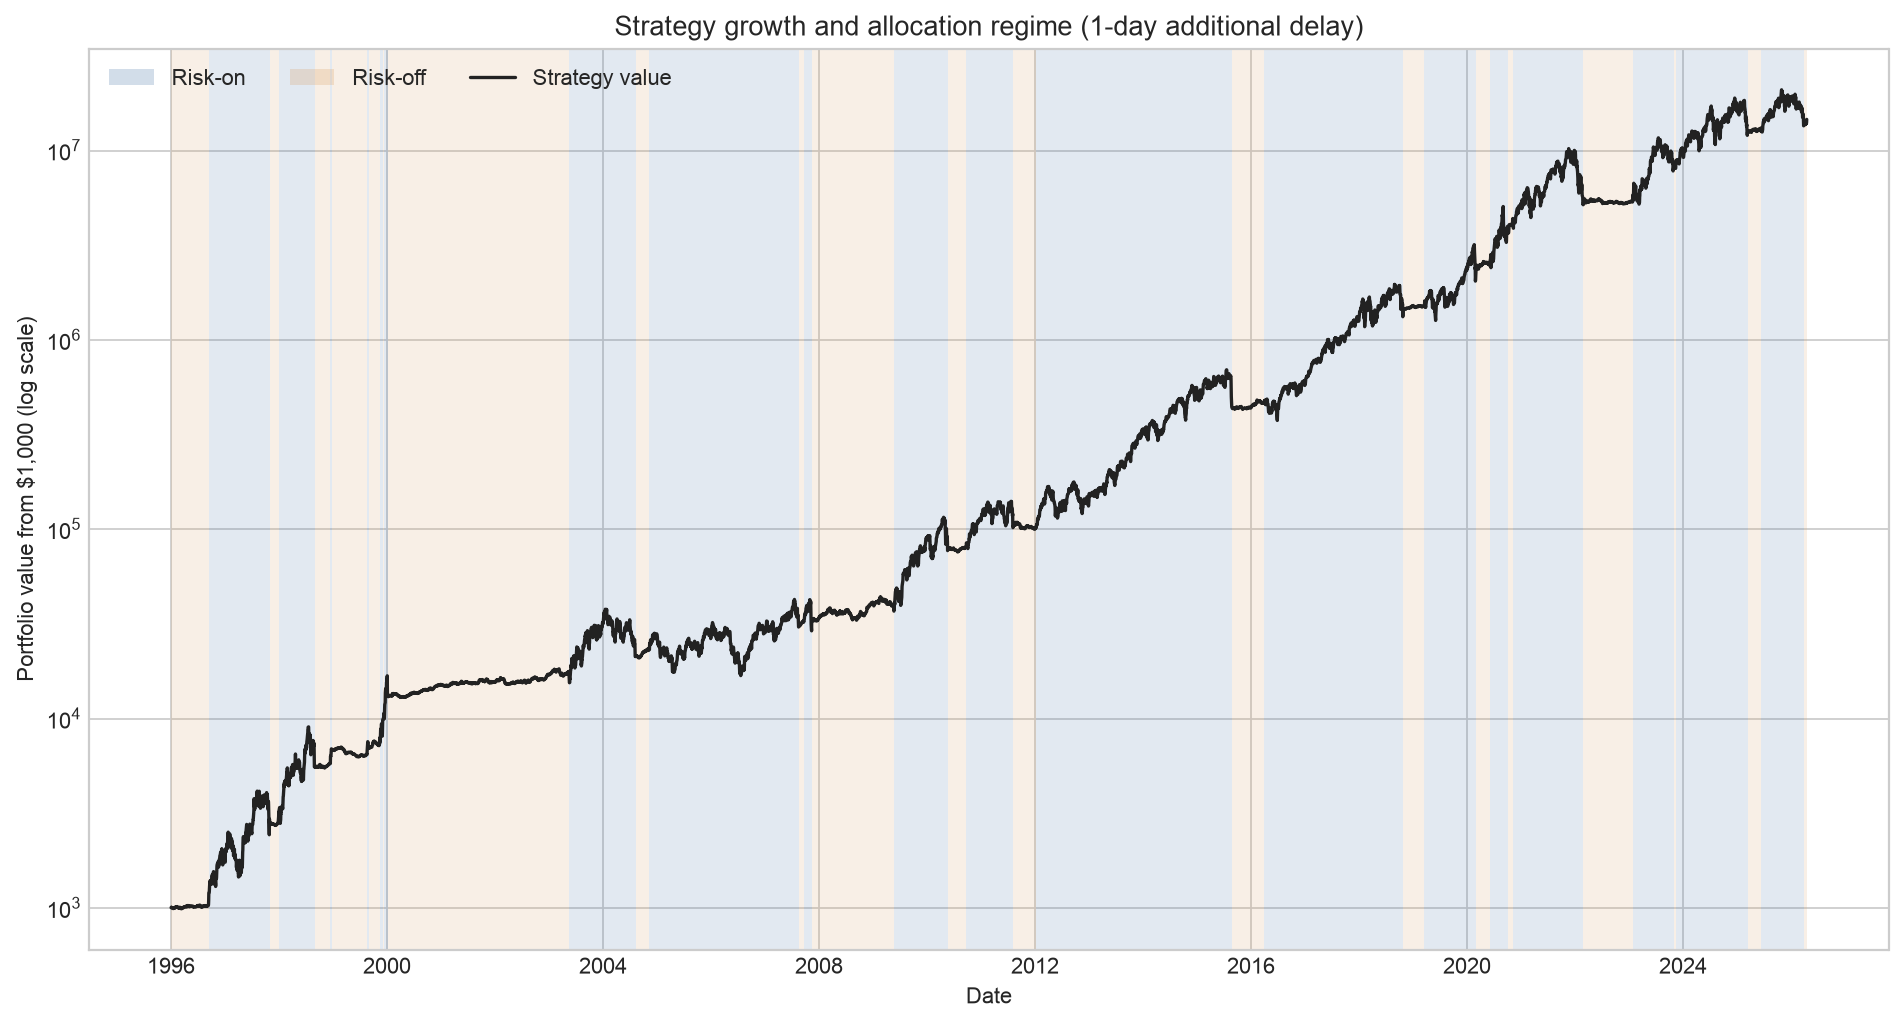

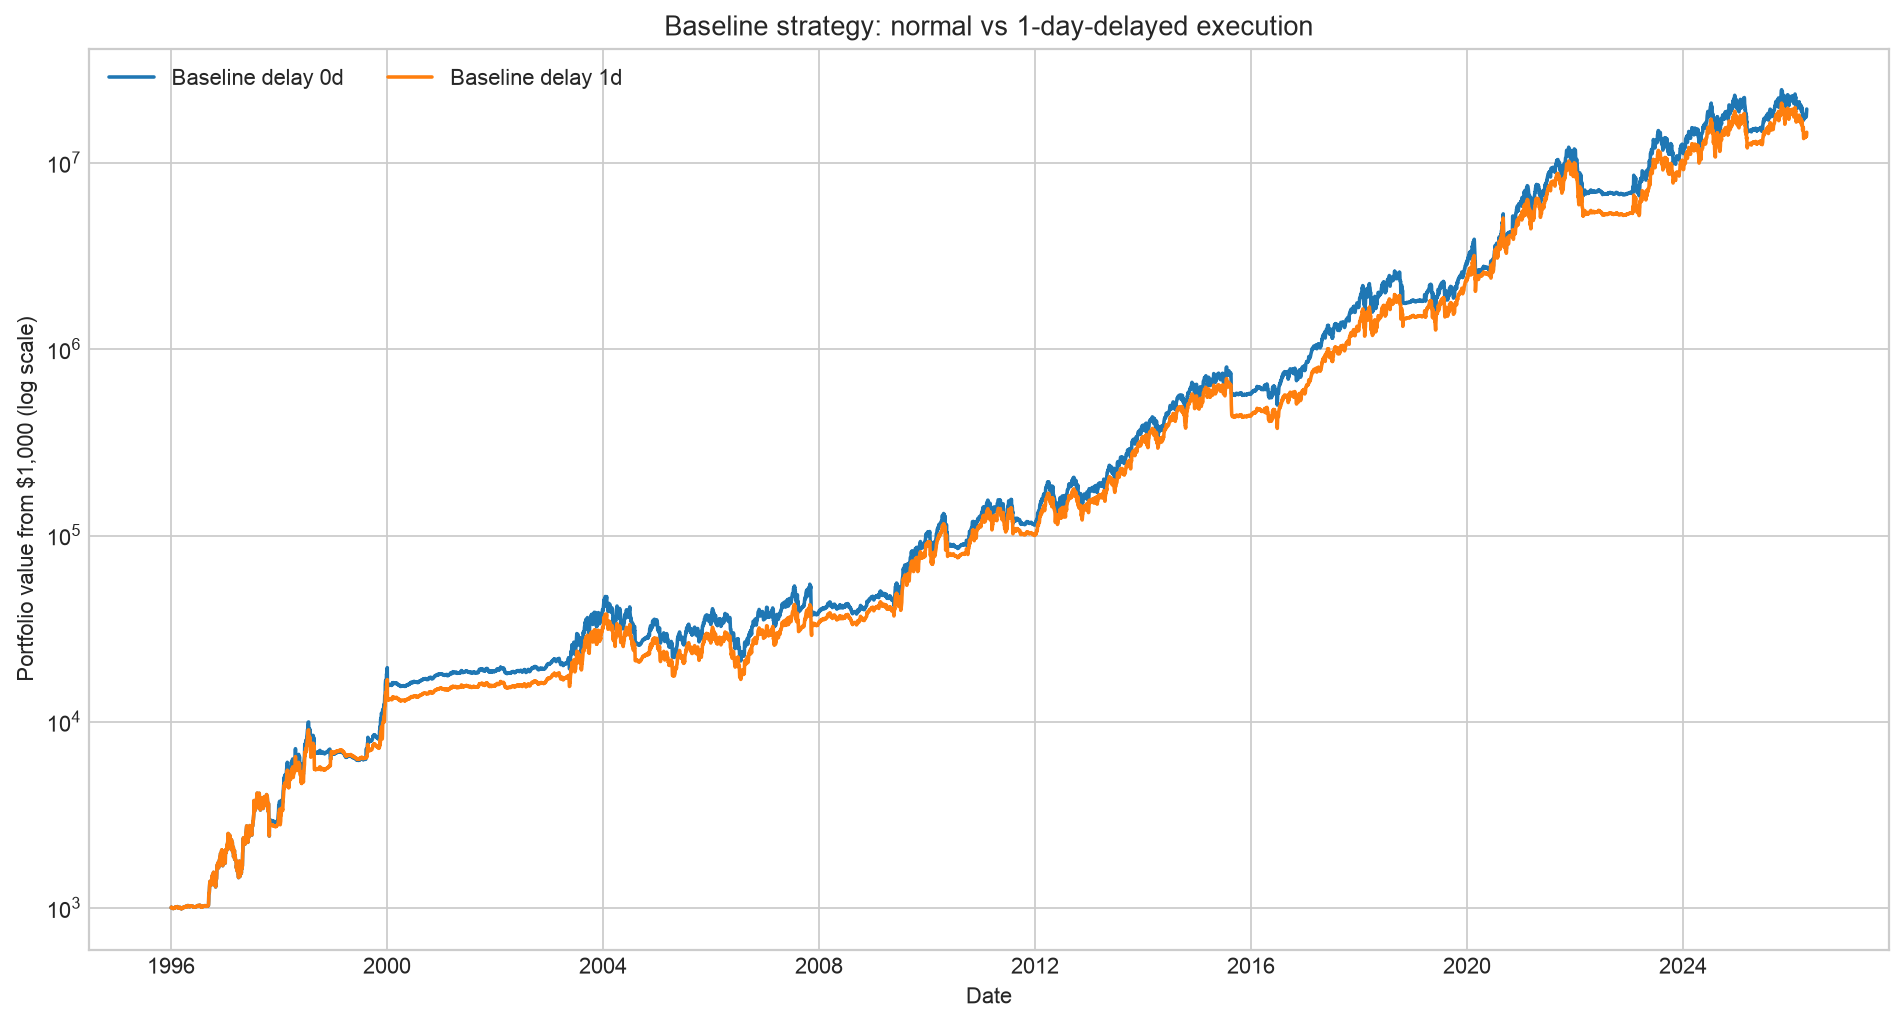

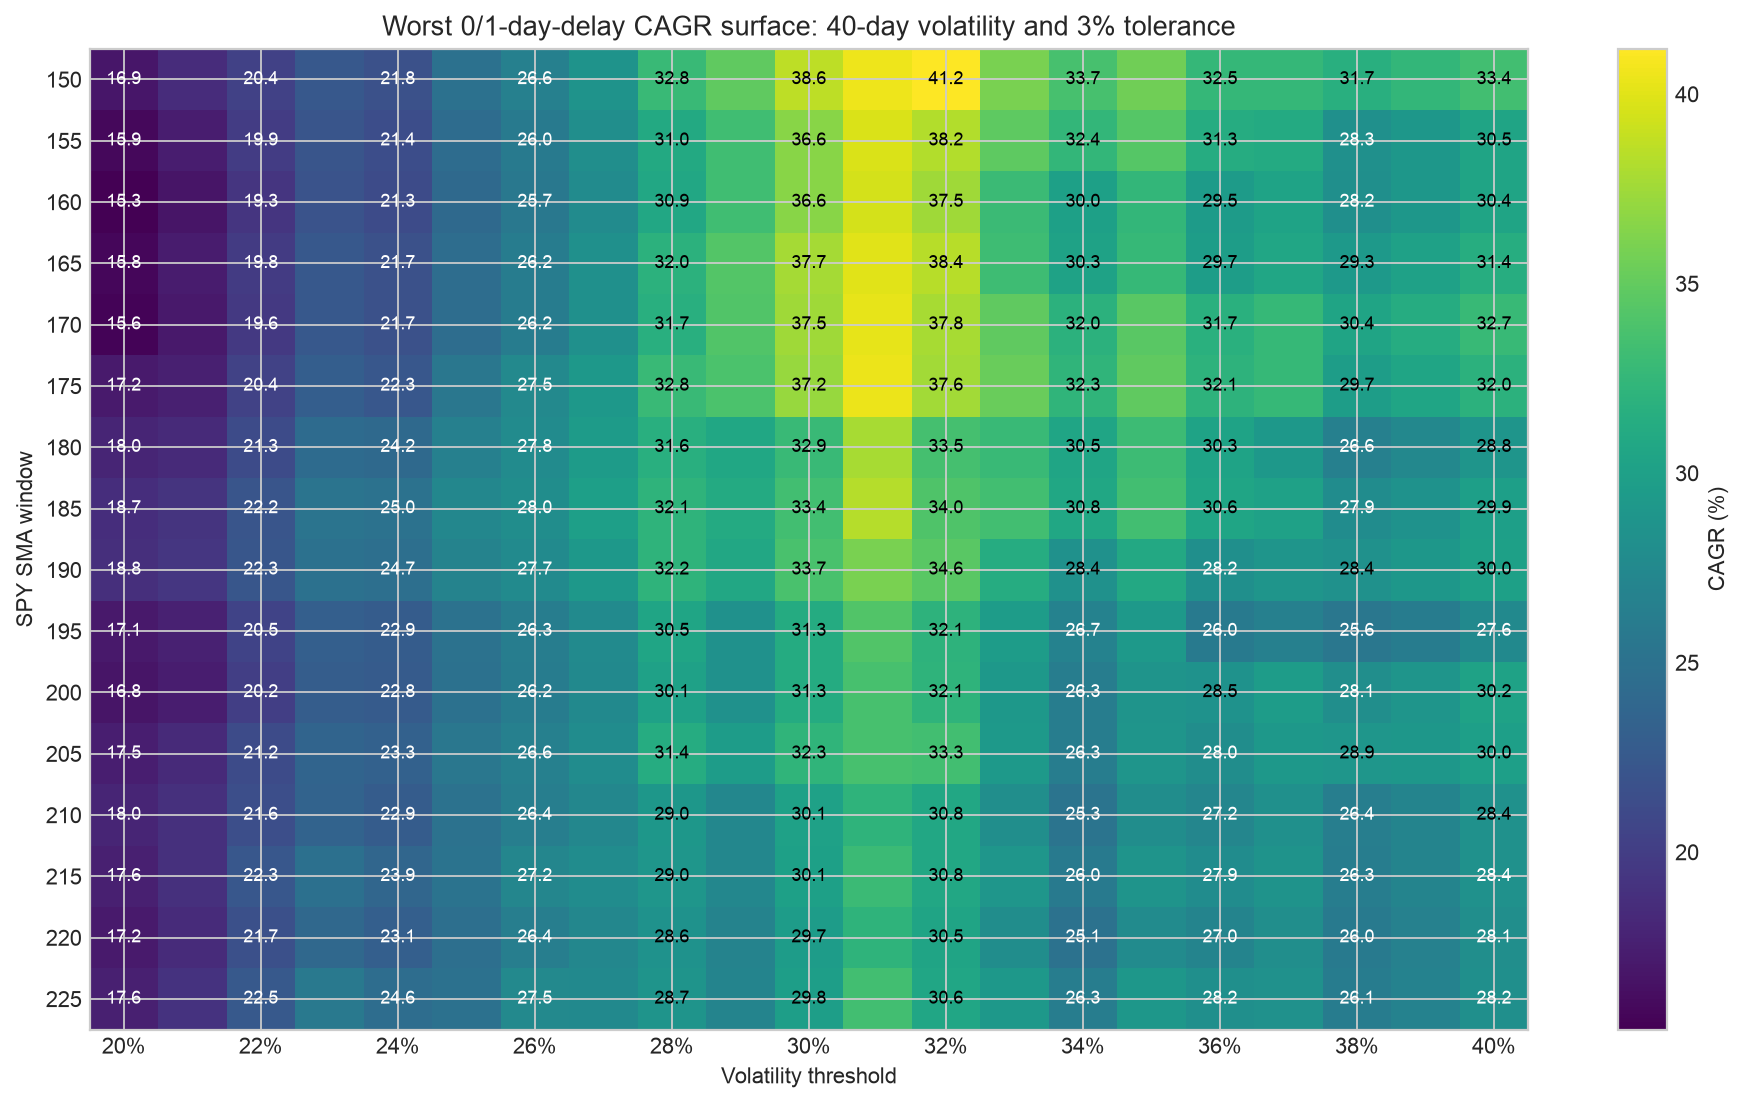

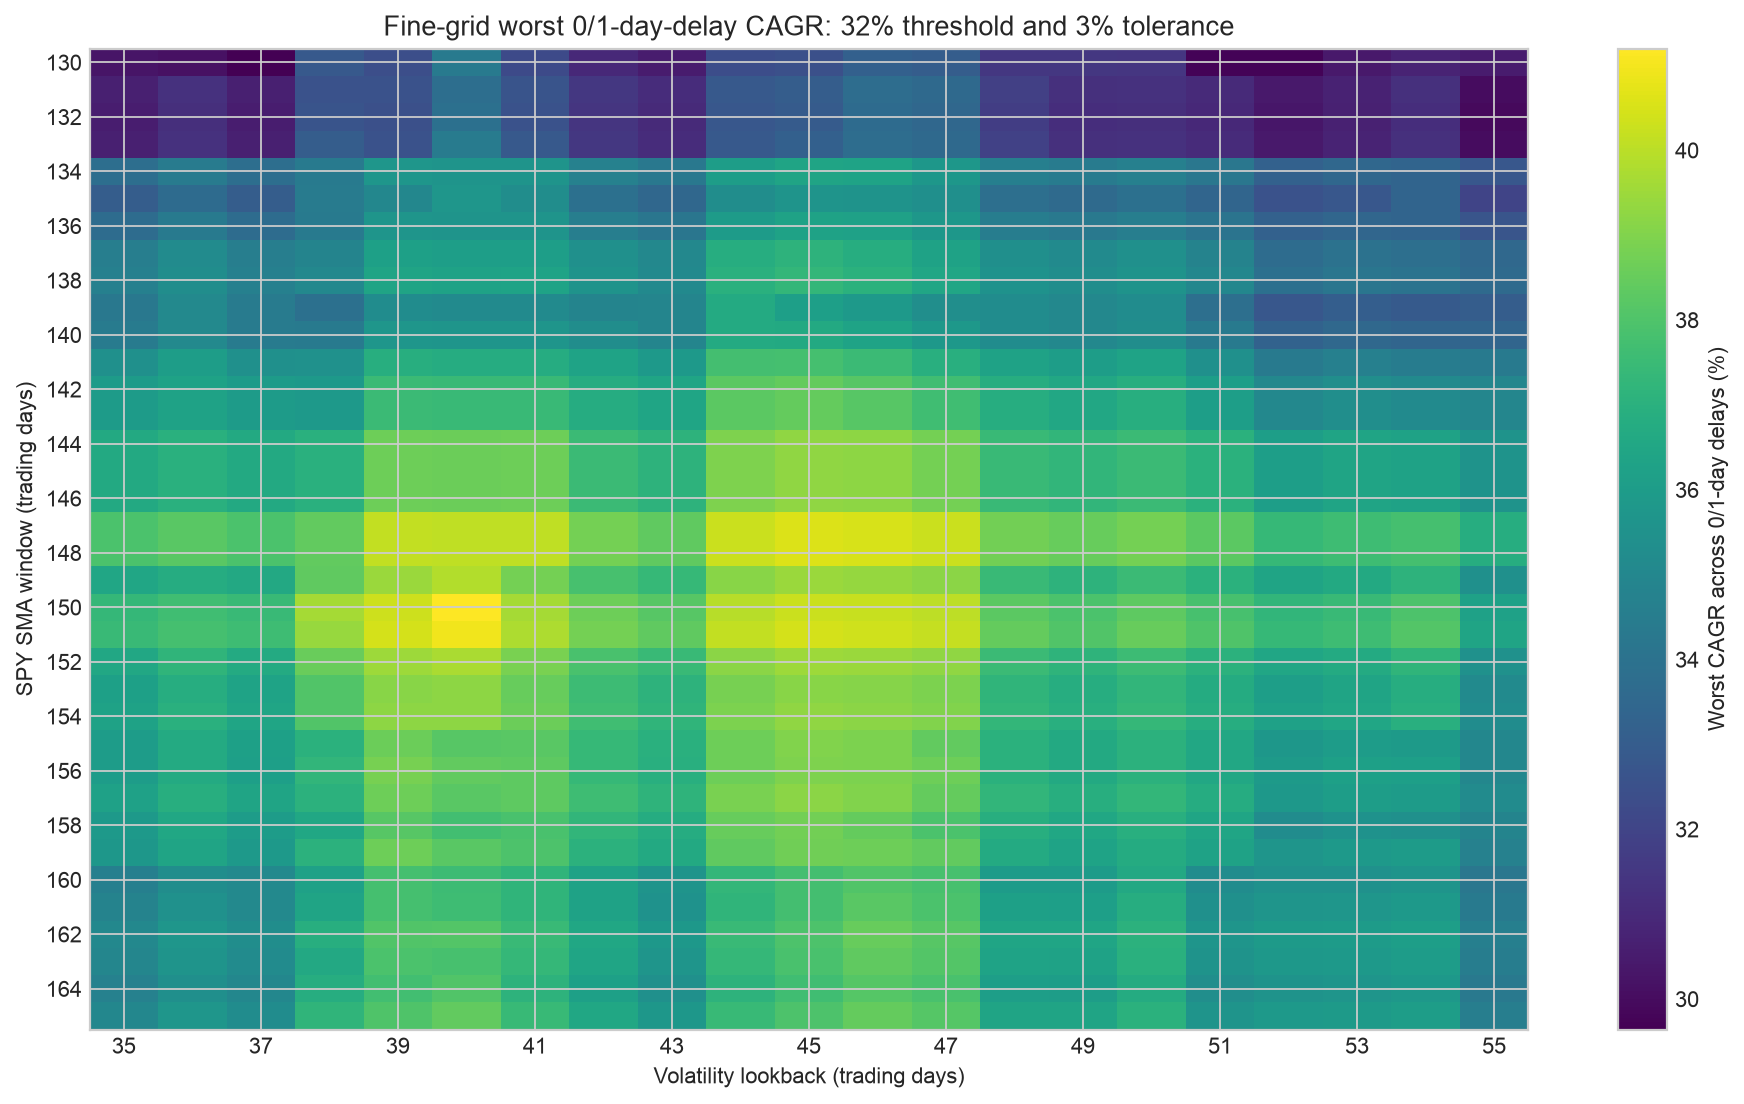

In [5]:
display(Image(filename=str(OUTPUT / 'recommended_regime_growth.png')))
display(Image(filename=str(OUTPUT / 'recommended_delay_equity_curves.png')))
display(Image(filename=str(OUTPUT / 'baseline_regime_growth.png')))
display(Image(filename=str(OUTPUT / 'baseline_delay_equity_curves.png')))
display(Image(filename=str(OUTPUT / 'cagr_parameter_surface.png')))
display(Image(filename=str(OUTPUT / 'refinement_robust_surface.png')))

## Takeaways

1. **175/40/30/3%は0日・1日遅延の両方で要件を通過**。最低CAGRは37.25%。
2. **全域では150/40/32/3%が最高**。両遅延中の最低CAGRは41.20%。
3. **細分化すると147〜151日・38〜46日・31〜32%・許容帯3%が連続した高成績領域**。
4. **最高点150/40/32/3%を将来も最良とは断定しない**。全期間インサンプルのため、帯の中央値とウォークフォワードを重視する。
5. **元戦略の最終認証ではない**。KMLMSIMは取込済みだが、GLDSIM・IEISIMと税引後ロット計算が残るため、総合評価は `Needs revision`。